In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder("Data", transform=transform)

NUM_CLASSES = len(dataset.classes)
print("Classes:", dataset.classes)

Classes: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


In [4]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return self.alpha * (1 - pt) ** self.gamma * ce_loss

In [6]:
def build_model(name):
    if name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    elif name == "mobilenet":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    elif name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    return model.to(device)

In [7]:
model1 = build_model("efficientnet")
model2 = build_model("resnet")
model3 = build_model("mobilenet")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Himal Rana/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 9.62MB/s]


In [8]:
def train_model(model, train_loader, val_loader, epochs=5):
    criterion = FocalLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # TRAIN
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc="Training")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = correct / total

        # VALIDATION
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            loop = tqdm(val_loader, desc="Validation")

            for images, labels in loop:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [9]:
model1 = train_model(model1, train_loader, val_loader, epochs=5)
model2 = train_model(model2, train_loader, val_loader, epochs=5)
model3 = train_model(model3, train_loader, val_loader, epochs=5)


Epoch 1/5


Validation: 100%|██████████| 222/222 [00:43<00:00,  5.12it/s]


Train Loss: 138.5973 | Train Acc: 0.7339
Val Loss: 16.2795 | Val Acc: 0.7842

Epoch 2/5


Validation: 100%|██████████| 222/222 [00:48<00:00,  4.55it/s]


Train Loss: 65.0020 | Train Acc: 0.7882
Val Loss: 10.6755 | Val Acc: 0.8196

Epoch 3/5


...

Train Loss: 47.5786 | Train Acc: 0.7950
Val Loss: 8.4536 | Val Acc: 0.8154

Epoch 4/5


Validation: 100%|██████████| 222/222 [00:35<00:00,  6.17it/s]


Train Loss: 39.2993 | Train Acc: 0.8120
Val Loss: 6.9772 | Val Acc: 0.8305

Epoch 5/5


Validation: 100%|██████████| 222/222 [00:42<00:00,  5.27it/s]

Train Loss: 33.1284 | Train Acc: 0.8266
Val Loss: 5.9969 | Val Acc: 0.8394


In [10]:
def ensemble_predict(models, loader):
    all_preds = []

    for model in models:
        model.eval()
        preds = []

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                outputs = model(images)
                preds.append(torch.softmax(outputs, dim=1).cpu().numpy())

        all_preds.append(np.concatenate(preds, axis=0))

    return np.mean(all_preds, axis=0)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

ensemble_preds = ensemble_predict([model1, model2, model3], test_loader)

y_pred = np.argmax(ensemble_preds, axis=1)

y_true = []
for _, labels in test_loader:
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.99      0.56      0.71       125
           2       1.00      0.69      0.81        67
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        75
           5       0.00      0.00      0.00        22
           6       1.00      0.30      0.46       140
           7       0.86      0.63      0.72       643
           8       1.00      0.07      0.14        95
           9       0.86      0.99      0.92      5149
          10       0.00      0.00      0.00         8
          11       0.75      0.37      0.50       211
          12       0.79      0.68      0.73       432
          13       0.96      0.57      0.72       117

    accuracy                           0.86      7087
   macro avg       0.59      0.35      0.41      7087
weighted avg       0.85      0.86      0.84      7087

[[   0    0    0    0    

d:\SVNIT\Semester - 6\Deep Learning\Practicals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\SVNIT\Semester - 6\Deep Learning\Practicals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\SVNIT\Semester - 6\Deep Learning\Practicals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None

        if hasattr(target_layer, "_backward_hooks"):
            target_layer._backward_hooks.clear()

        self._forward_handle = target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, _module, _input, output):
        if _module is None or _input is None:
            return

        self.activations = output
        if self.activations.requires_grad:
            self.activations.retain_grad()

    def generate(self, input_image):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        input_image = input_image.clone().detach().requires_grad_(True)
        output = self.model(input_image)

        class_idx = output.argmax(dim=1).item()
        output[:, class_idx].sum().backward()

        if self.activations is None or self.activations.grad is None:
            raise RuntimeError("GradCAM hooks did not capture gradients.")

        gradients = self.activations.grad[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))
        cam = torch.zeros_like(activations[0])

        for i, weight in enumerate(weights):
            cam += weight * activations[i]

        cam = torch.relu(cam)
        cam = cam / cam.max().clamp(min=1e-8)

        return cam.detach().cpu().numpy()

In [13]:
def get_target_layer(model):
    if hasattr(model, "layer4"):
        return model.layer4[-1]
    if hasattr(model, "features"):
        return model.features[-1]
    raise ValueError("Unsupported model architecture for Grad-CAM.")


def show_gradcam(img_path, model):
    img = Image.open(img_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    target_layer = get_target_layer(model)
    cam = GradCAM(model, target_layer)

    heatmap = cam.generate(input_tensor)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img = np.array(img.resize((224, 224)))
    superimposed = np.clip(heatmap * 0.4 + img, 0, 255)

    plt.imshow(superimposed.astype(np.uint8))
    plt.axis('off')
    plt.show()

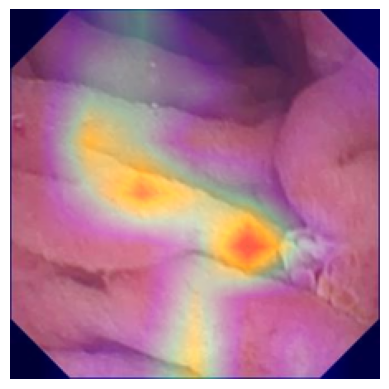

In [14]:
show_gradcam("Data/ampulla_of_vater/eb0203196e284797_1157.jpg", model2)